In [126]:
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid
from scipy.special import erfc
from fit_functions import R_sq, EMG, EMG_mirrored, make_constrained_EMG, make_constrained_EMG_mirrored, make_constrained_EMGsTailFront, make_sigma_constrained_EMG, make_sigma_constrained_EMG_mirrored


## Calibration

In [127]:
# Calibration data, all masses in g, all areas in arbitrary units, all concentrations in wt% (mass of solute / total mass)
MeOH = {
    'name': 'Methanol',
    'water': np.array([1, 1.0044, 1.0024, 1.0071, 0.7143]),
    'MeOH': np.array([0, 0.1644, 0.1184, 0.0525, 0.1927]),
    'areas': np.array([0, 675785, 511686, 238447, 1008072])
}
FA = {
    'name': 'Formic Acid',
    'water': np.array([1, 0.9708, 0.9620, 0.9157, 0.9194, 0.9276, 1.1981]),
    'FA': np.array([0, 0.0410, 0.0758, 0.2071, 0.4549, 0.1422, 0.0191]),
    'areas': np.array([0, 556879, 984689, 2469722, 4456892, 1782368, 198684])
}
FAld = {
    'name': 'Formaldehyde',
    'water': np.array([1, 0.8533, 0.8868, 0.7250, 0.5555, 1.0525]),
    'FAld': np.array([0, 0.4061, 0.2224, 0.4548, 0.6975, 0.1297]),
    'areas': np.array([0, 3277991, 1975810, 3911989, 5744917, 1078320])
}

# Convert masses to wt% concentration for each calibration series
calibrations = [
    (MeOH, 'MeOH', 100),
    (FA, 'FA', 100),
    (FAld, 'FAld', 37),
]

for dictionary, solute_key, factor in calibrations:
    # wt% = mass of solute / total mass, scaled by mass concentration factor in stock solution (100% for MeOH and FA, 37% for FAld)
    dictionary['concentrations'] = factor * dictionary[solute_key] / (dictionary[solute_key] + dictionary['water'])

header = f"{'FAld wt%':<10} {'FA wt%':<10} {'MeOH wt%':<10}"
print(header)
print("-" * len(header))
max_len = max(len(FAld['concentrations']), len(FA['concentrations']), len(MeOH['concentrations']))
for index in range(max_len):
    fa_ld = FAld['concentrations'][index] if index < len(FAld['concentrations']) else '-'
    fa = FA['concentrations'][index] if index < len(FA['concentrations']) else '-'
    meoh = MeOH['concentrations'][index] if index < len(MeOH['concentrations']) else '-'
    print(
        f"{fa_ld:<10.2f}" if isinstance(fa_ld, (int, float, np.floating)) else f"{fa_ld:<10}",
        f"{fa:<10.2f}" if isinstance(fa, (int, float, np.floating)) else f"{fa:<10}",
        f"{meoh:<10.2f}" if isinstance(meoh, (int, float, np.floating)) else f"{meoh:<10}",
    )

FAld wt%   FA wt%     MeOH wt%  
--------------------------------
0.00       0.00       0.00      
11.93      4.05       14.07     
7.42       7.30       10.56     
14.26      18.44      4.95      
20.60      33.10      21.25     
4.06       13.29      -         
-          1.57       -         


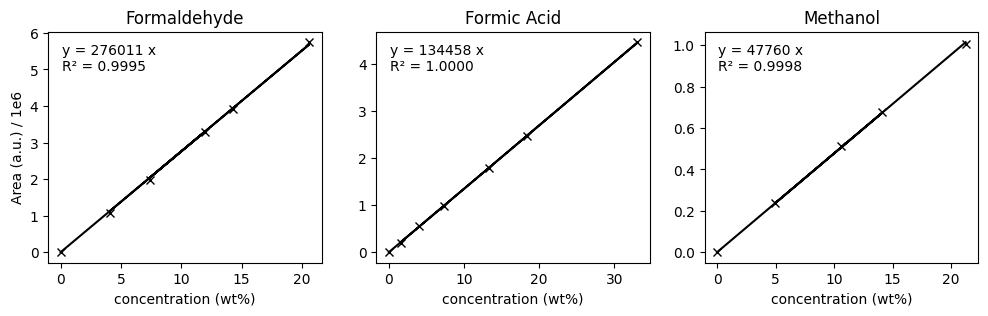

In [128]:
# calculate fit parameters and R² for each calibration series
for dictionary in np.array([FAld, FA, MeOH]):                                                                                      
    m, residuals, _, _ = np.linalg.lstsq(dictionary['concentrations'].reshape(-1,1), dictionary['areas'])
    slope = m[0]
    dictionary['slope'] = slope                                                                                          
    r2 = R_sq(lambda x: slope*x, dictionary['concentrations'], dictionary['areas'])
    dictionary['r2'] = r2

# plot
fig, (ax1, ax2, ax3) = plt.subplots(figsize = (12, 3), ncols = 3)                                 
for dictionary, ax in zip(np.array([FAld, FA, MeOH]), [ax1, ax2, ax3]):                                           
    ax.plot(dictionary['concentrations'], dictionary['areas']/1e6, 'kx')            
    ax.plot(dictionary['concentrations'], dictionary['concentrations']*dictionary['slope']/1e6, 'k-')     
    ax.set_title(dictionary['name'])                                                                
    ax.set_xlabel('concentration (wt%)')                                                            
    eq_text = f"y = {dictionary['slope']:.0f} x\nR² = {dictionary['r2']:.4f}"
    ax.text(0.05, 0.95, eq_text, transform=ax.transAxes, va='top')
ax1.set_ylabel('Area (a.u.) / 1e6')                                                                 
plt.show()

## Chromatogram Extraction

In [129]:
def extract_chromatogram(filepath):                                         # definiere funktion
    with open(filepath, 'r', encoding='latin1') as f:                       # öffne file as f im lesemode
        lines = f.readlines()                                               # lies die zeilen

    for i, line in enumerate(lines):
        if line.strip().startswith('[LC Chromatogram(Detector B-Ch1)]'):    # sucht start des chromatogramms
            data_start = i + 8                                              # Skip 8 header lines
            break                                                           # brich loop ab, start gefunden

    data_lines = [] 
    for line in lines[data_start:]:                                         # fang beim start neuen loop an
        if not line.strip() or line.strip().startswith('['):                # abbrechen, wenn leere zeile
            break
        data_lines.append(line)                                             # sonst, zeile an data lines anhängen

    data = np.genfromtxt(data_lines, usecols=(0,1))                         # extract data
    data_export = np.column_stack([60*data[:,0], data[:,1]])                # time --> s 
    return data_export                                                      # return the data for chromatogram

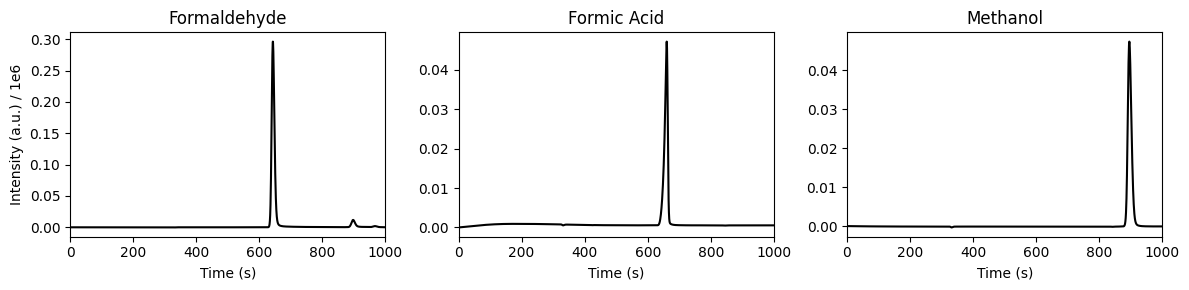

In [130]:
path = 'data/calibration/'
file = ['CAL-FALD-1.txt', 'CAL-FA-1.txt', 'CAL-MeOH-1.txt']

# load samples for each calibration (FAld, FA, MeOH)
samples = [extract_chromatogram(path + f) for f in file]
index_1, index_2 = 0, 2000

fig, axes = plt.subplots(ncols=3, figsize=(12,3))  # explicit axes (three columns)
titles = ['Formaldehyde', 'Formic Acid', 'Methanol']
for ax, samp, title in zip(axes, samples, titles):
    ax.plot(samp[index_1:index_2,0], samp[index_1:index_2,1]/1e6, 'k-')
    ax.set_xlim(samp[index_1,0], samp[index_2,0])
    ax.set_title(title)

axes[0].set_ylabel('Intensity (a.u.) / 1e6')
for ax in axes:
    ax.set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

## Sigma and Tau determination for Formaldehyde 

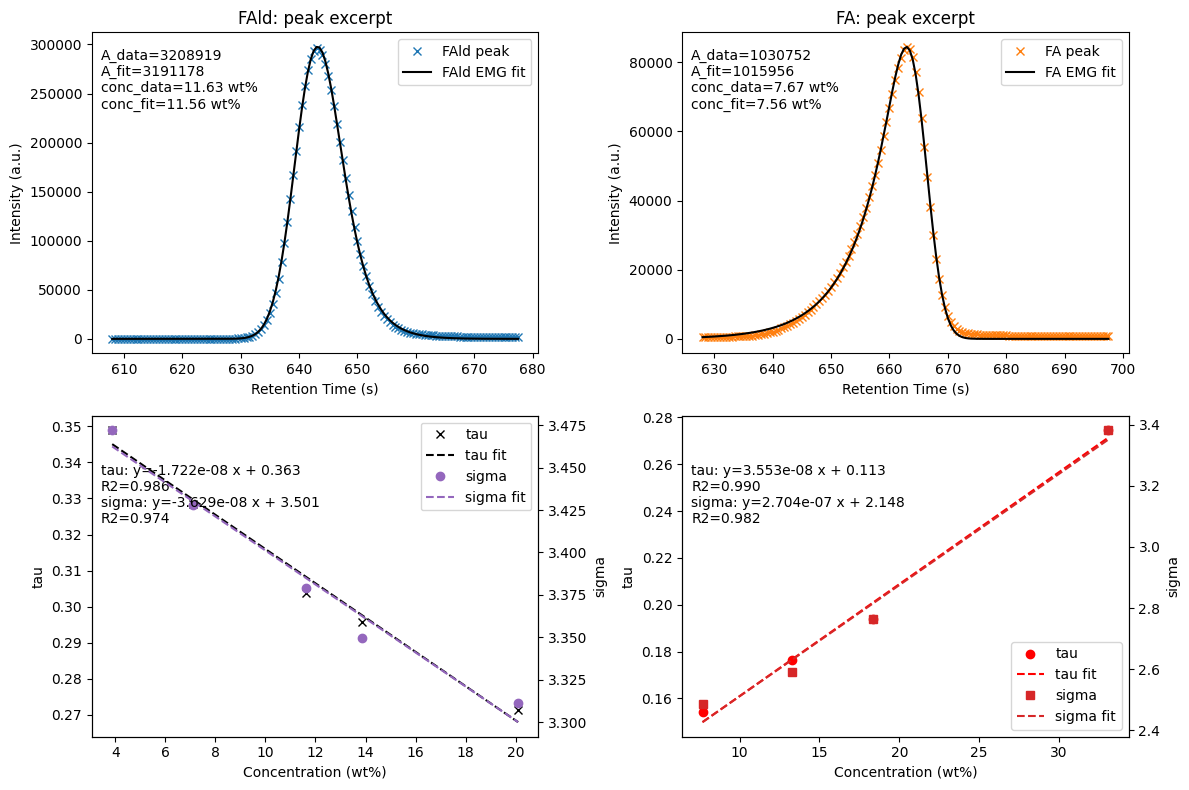

In [131]:
import glob
path_1 = 'data/calibration/'
fald_files = sorted(glob.glob(path_1 + 'CAL-FALD-*.txt'))
fa_files = sorted(glob.glob(path_1 + 'CAL-FA-*.txt'))

def analyze_calibration(files, species):
    areas, hs, taus, sigmas, used_files = [], [], [], [], []
    model = EMG if species == 'FAld' else EMG_mirrored
    sigma0, tau0 = (3.3, 0.31) if species == 'FAld' else (2.5, 0.18)
    for fp in files:
        try:
            sample = extract_chromatogram(fp)
        except Exception:
            continue
        idx_max = np.argmax(sample[:,1])
        i1, i2 = max(0, idx_max - 70), min(len(sample), idx_max + 70)
        x = sample[i1:i2,0]
        y = sample[i1:i2,1]
        p0 = [np.max(y), x[np.argmax(y)], sigma0, tau0]
        try:
            popt, _ = sc.optimize.curve_fit(model, x, y, p0=p0, maxfev=20000)
        except Exception:
            continue
        h, mu, sigma, tau = popt
        used_files.append(fp)
        areas.append(trapezoid(y, x))
        hs.append(h)
        taus.append(tau)
        sigmas.append(sigma)
    return np.array(areas), np.array(hs), np.array(taus), np.array(sigmas), used_files

def fit_info(x, y):
    if len(x) < 2:
        return None
    coeffs = np.polyfit(x, y, 1)
    return coeffs, R_sq(np.poly1d(coeffs), x, y)

FAld_area_arr, FAld_h_arr, FAld_tau_arr, FAld_width_arr, FAld_used = analyze_calibration(fald_files, 'FAld')
FA_area_arr, FA_h_arr, FA_tau_arr, FA_width_arr, FA_used = analyze_calibration(fa_files, 'FA')

if len(FA_area_arr) > 2:
    remove = np.argsort(FA_area_arr)[:2]
    keep = np.ones(len(FA_area_arr), dtype=bool)
    keep[remove] = False
    FA_area_arr = FA_area_arr[keep]
    FA_h_arr = FA_h_arr[keep]
    FA_tau_arr = FA_tau_arr[keep]
    FA_width_arr = FA_width_arr[keep]
    FA_used = [fp for fp, ok in zip(FA_used, keep) if ok]

FAld_fit_tau = fit_info(FAld_area_arr, FAld_tau_arr)
FAld_fit_sig = fit_info(FAld_area_arr, FAld_width_arr)
FA_fit_tau = fit_info(FA_area_arr, FA_tau_arr)
FA_fit_sig = fit_info(FA_area_arr, FA_width_arr)

def plot_peak(ax, fp, model, color, sigma_guess, tau_guess, title, slope):
    sample = extract_chromatogram(fp)
    idx_max = np.argmax(sample[:,1])
    i1, i2 = max(0, idx_max - 70), min(len(sample), idx_max + 70)
    x = sample[i1:i2,0]
    y = sample[i1:i2,1]
    p0 = [np.max(y), x[np.argmax(y)], sigma_guess, tau_guess]
    try:
        popt, _ = sc.optimize.curve_fit(model, x, y, p0=p0, maxfev=20000)
        fit = model(x, *popt)
    except Exception:
        popt, fit = None, None
    ax.plot(x, y, color + 'x', label=f'{title} peak')
    if fit is not None:
        ax.plot(x, fit, 'k-', label=f'{title} EMG fit')
    A_data = trapezoid(y, x)
    A_fit = popt[0] if popt is not None else np.nan
    conc_data = A_data / slope
    conc_fit = A_fit / slope if popt is not None else np.nan
    ax.text(0.02, 0.95, f'A_data={A_data:.0f}\nA_fit={A_fit:.0f}\nconc_data={conc_data:.2f} wt%\nconc_fit={conc_fit:.2f} wt%', transform=ax.transAxes, va='top')
    ax.set_title(f'{title}: peak excerpt')
    ax.set_xlabel('Retention Time (s)')
    ax.set_ylabel('Intensity (a.u.)')
    ax.legend()

def plot_calibration(ax, area_arr, tau_arr, wid_arr, slope, fit_tau, fit_sig, tau_color, sig_color, label):
    if len(area_arr) == 0:
        ax.text(0.5, 0.5, f'No {label} calibration points', ha='center', va='center')
        return
    conc = area_arr / slope
    ax2 = ax.twinx()
    ax.plot(conc, tau_arr, tau_color, label='tau')
    ax2.plot(conc, wid_arr, sig_color, label='sigma')
    xs = np.linspace(np.min(conc), np.max(conc), 100)
    tau_fit_color = tau_color[:2] if tau_color.startswith('C') else tau_color[0]
    sig_fit_color = sig_color[:2] if sig_color.startswith('C') else sig_color[0]
    if fit_tau is not None:
        coeffs, r2 = fit_tau
        ax.plot(xs, np.poly1d(coeffs)(xs * slope), color=tau_fit_color, linestyle='--', label='tau fit')
        ax.text(0.02, 0.85, f'tau: y={coeffs[0]:.3e} x + {coeffs[1]:.3f}\nR2={r2:.3f}', transform=ax.transAxes, va='top')
    if fit_sig is not None:
        coeffs, r2 = fit_sig
        ax2.plot(xs, np.poly1d(coeffs)(xs * slope), color=sig_fit_color, linestyle='--', label='sigma fit')
        ax2.text(0.02, 0.75, f'sigma: y={coeffs[0]:.3e} x + {coeffs[1]:.3f}\nR2={r2:.3f}', transform=ax2.transAxes, va='top')
    ax.set_xlabel('Concentration (wt%)')
    ax.set_ylabel('tau')
    ax2.set_ylabel('sigma')
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc='best')

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_peak(axes[0,0], FAld_used[0], EMG, 'C0', FAld_width_arr[0] if len(FAld_width_arr) else 3.3, FAld_tau_arr[0] if len(FAld_tau_arr) else 0.31, 'FAld', FAld['slope']) if len(FAld_used) else axes[0,0].text(0.5, 0.5, 'No FAld data', ha='center', va='center')
plot_peak(axes[0,1], FA_used[0], EMG_mirrored, 'C1', FA_width_arr[0] if len(FA_width_arr) else 2.5, FA_tau_arr[0] if len(FA_tau_arr) else 0.18, 'FA', FA['slope']) if len(FA_used) else axes[0,1].text(0.5, 0.5, 'No FA data', ha='center', va='center')
plot_calibration(axes[1,0], FAld_area_arr, FAld_tau_arr, FAld_width_arr, FAld['slope'], FAld_fit_tau, FAld_fit_sig, 'kx', 'C4o', 'FAld')
plot_calibration(axes[1,1], FA_area_arr, FA_tau_arr, FA_width_arr, FA['slope'], FA_fit_tau, FA_fit_sig, 'ro', 'C3s', 'FA')
fig.tight_layout()
plt.show()

In [132]:
# Sigma and Tau determination for Formic Acid
path_1 = '../01_unprocessed_data/HPLC/Calibration/Calibration_35C/FormicAcid/' # 35°C
file_1 = ['FKE-Cal-FA-2-1.txt', 'FKE-Cal-FA-2-2.txt', 'FKE-Cal-FA-2-3.txt', 'FKE-Cal-FA-2-4.txt', 'FKE-Cal-FA-2-5.txt', 'FKE-Cal-FA-2-6.txt']

sample = extract_chromatogram(path_1 + file_1[2])                                                                                # Extract Chromatogram
index_1, index_2 = np.argmax(sample[:,1])-70, np.argmax(sample[:,1])+70                                                          # Define start and end indices

initial_guess = [5e5, 642, 5, 0.2]                                                                                               # Define initial guesses
popt, _ = sc.optimize.curve_fit(EMG_mirrored, sample[:,0], sample[:,1], p0 = initial_guess)                                      # Optimize

print(f'optimized parameters h, mu, sigma, tau: {popt}')                                                                         # Print popt
print('-'*32)
h, mu, sigma, tau = popt                                                                                                         # Extract popt
EMG_1 = EMG_mirrored(sample[index_1:index_2,0], h, mu, sigma, tau)                                                               # Generate fitfunction

# calculate area from data, print results
A = trapezoid(sample[index_1:index_2,1], sample[index_1:index_2,0], axis=0)                                                      # Area from Data
print(f'Area from data: {round(A,2)}')                                                                                           # Print Area from Data 
print(f'Area from fit: {round(h,2)}')                                                                                            # Print Area from Fit
print(f'Concentration from data: {round(A/FA["slope"],2)} wt%')                                                                  # Print Concentration from Data
print(f'Concentration from fit: {round(h/FA["slope"],2)} wt%')                                                                   # Print Concentration from Fit 
print(f'Peak maximum {round(sample[index_1:index_2,0][np.argmax(EMG_1)],2)} s')                                                  # Print Peak Maxima
print('-'*32)

fig, (ax1, ax2) = plt.subplots(ncols=2)                                                                                          # Create Figure
ax1.plot(sample[index_1:index_2,0], sample[index_1:index_2,1], 'C0x')                                                            # Plot data
ax1.plot(sample[index_1:index_2,0], EMG_1, color='k')                                                                            # Plot Fit
ax1.set_xlim(sample[index_1,0], sample[index_2,0])                                                                               # Set xlim

FA_area_arr = np.array([7.30, 18.44, 33.10, 13.29]) * FA['slope']                                                                # Calculate Areas
FA_tau_arr = np.array([0.1541, 0.1938, 0.2746, 0.1762])                                                                          # Hardcoded simulated taus
FA_coeffs_tau = np.polyfit(FA_area_arr, FA_tau_arr, 1)                                                                           # Linear fit for tau
print(f'FA_tau (m,b) = {FA_coeffs_tau}')                                                                                         # print fit coefficients
print(f"R² = {R_sq(np.poly1d(FA_coeffs_tau), FA_area_arr, FA_tau_arr):.4f}")                                                                          # print R^2

FA_width_arr = np.array([2.485, 2.764, 3.382, 2.591])                                                                            # Hardcoded simulated sigmas
FA_coeffs_wid = np.polyfit(FA_area_arr, FA_width_arr, 1)                                                                         # Linear fit for sigma
print(f'FA_sigma (m,b) = {FA_coeffs_wid}')                                                                                       # print fit coefficients
print(f"R² = {R_sq(np.poly1d(FA_coeffs_wid), FA_area_arr, FA_width_arr):.4f}")                                                                        # print R^2
print('-'*32)

ax2.plot(FA_area_arr/FA['slope'], FA_tau_arr, 'kx')                                                                              # tau-Plot
ax2_2 = ax2.twinx()
ax2_2.plot(FA_area_arr/FA['slope'], FA_width_arr, 'C4o')                                                                         # sigma-Plot
ax1.set_xlabel('Retention Time (s)')
ax1.set_ylabel('Intensity (a.u.)')
ax2.set_xlabel('Concentration (wt%)')
ax2.set_ylabel(r'$\tau$')
ax2_2.set_ylabel(r'$\sigma$')
fig.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../01_unprocessed_data/HPLC/Calibration/Calibration_35C/FormicAcid/FKE-Cal-FA-2-3.txt'

In [ ]:
#Tests with preset FAld and FA concentration
FAld_conc, FA_conc = 5.64, 9.53                                                     # wt% of base concentrations
Names = np.array(['FAFAld1', 'FAFAld2', 'FAFAld3', 'FAFAld4', 'FAFAld5', 'FAFALD6'])                      # Names of the mixtures
FAld_mass = np.array([0.4588, 0.9178, 0.6543, 0.5735, 0.4492,0.2454])                              # masses FAld
FA_mass = np.array([0.6864, 0.3066, 0.5077, 0.9715, 0.5593,0.3887]) 
Water_mass = np.array([0, 0, 0, 0, 0.4244,0.6128])                               # masses FA
wt_perc_FAld = FAld_conc*FAld_mass/(FAld_mass+FA_mass+Water_mass)                              # calculation of wt%
wt_perc_FA = FA_conc*FA_mass/(FAld_mass+FA_mass+Water_mass)

print('Concentrations measured at 40°C and 35°C on 23.05 bzw. 27.05, here 35°C')    # print table 1 
print(f"{'Name':<10} {'wt% FAld':>10} {'wt% FA':>10}")
print("-" * 32)
for name, wtFAld, wtFA in zip(Names, wt_perc_FAld, wt_perc_FA):
    print(f"{name:<10} {wtFAld:10.2f} {wtFA:10.2f}")
#----------------------------------------------------------------------------#

print()
print('Concentrations measured at 35 °C on 27.05')
print(f"{'Name':<10} {'wt% FAld':>10} {'wt% FA':>10}")
print("-" * 32)
for name, wtFAld, wtFA in zip(Names, wt_perc_FAld, wt_perc_FA):
    print(f"{name:<10} {wtFAld:10.2f} {wtFA:10.2f}")

Concentrations measured at 40°C and 35°C on 23.05 bzw. 27.05, here 35°C
Name         wt% FAld     wt% FA
--------------------------------
FAFAld1          2.26       5.71
FAFAld2          4.23       2.39
FAFAld3          3.18       4.16
FAFAld4          2.09       5.99

Concentrations measured at 35 °C on 27.05
Name         wt% FAld     wt% FA
--------------------------------
FA1              0.00       4.33
FA2              0.00       5.97
FAld1            3.52       0.00
FAld2            1.44       0.00
FAFAld1          1.77       3.72
FAFAld2          1.11       2.97


1218 1358


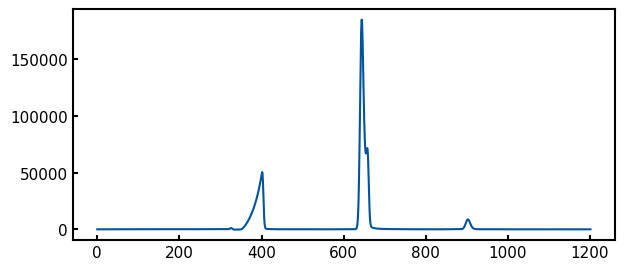

In [ ]:
path_1 = '../01_unprocessed_data/HPLC/Calibration/Calibration_35C/FA_FAld/'
files_1 = ['FKE-CAL-FALD-FA-HPLC-1.txt', 'FKE-CAL-FALD-FA-HPLC-2.txt', 'FKE-CAL-FALD-FA-HPLC-3.txt', 'FKE-CAL-FALD-FA-HPLC-4.txt']

path_2 = '../01_unprocessed_data/HPLC/Calibration/Calibration_35C/FA_FAld_2/'
files_2 = ['FKE-Test-FA-1.txt', 'FKE-Test-FA-2.txt', 'FKE-Test-FALD-1.txt', 'FKE-Test-FALD-2.txt', 'FKE-Test-FAFALD-1.txt', 'FKE-Test-FAFALD-2.txt']

path_e = '../01_unprocessed_data/HPLC/Electrolytes/'
path_s = '../01_unprocessed_data/HPLC/Educts/'
path_r = '../01_unprocessed_data/HPLC/Reactions/'
files_s = ['FKE-SOL-007-HPLC-2.txt', 'FKE-SOL-008-HPLC-1.txt', 'FKE-SOL-008-2-HPLC-1.txt', 'FKE-SOL-008-3-HPLC-1.txt', 'FKE-SOL-009-HPLC-1.txt', 'FKE-SOL-008-4-HPLC-1']
files_r = ['FKE-EXP-015-HPLC-1.txt', 'FKE-EXP-016-HPLC-1.txt', 'FKE-EXP-017-HPLC-1.txt', 'FKE-EXP-018-HPLC-2.txt', 'FKE-EXP-019-HPLC-1.txt', 'FKE-EXP-020-HPLC-1.txt',
            'FKE-EXP-021-HPLC-1.txt', 'FKE-EXP-022-HPLC-1.txt','FKE-EXP-023-HPLC-1.txt', 'FKE-EXP-024-HPLC-1.txt','FKE-EXP-025-HPLC-1.txt', 'FKE-EXP-026-HPLC-1.txt']
file = 'FKE-EXP-022-HPLC-1'
sample = extract_chromatogram(path_r+file+'.txt')
sample_name = file

mask = (sample[:, 0] >= 500) & (sample[:, 0] <= 750)
masked_indices = np.where(mask)[0]
index_1 = masked_indices[np.argmax(sample[mask, 1])]-70
index_2 = index_1 + 140
print(index_1, index_2)
plt.plot(sample[:,0], sample[:,1])
plt.show()

In [ ]:
beta = 10.91/100
rho = 1.073
mole_per_l = 1000*beta*rho/30.03

print(mole_per_l)

print(22.5/3.4)
print(51.62*0.5)
print(6.62*3.9)

3.8982450882450883
6.61764705882353
25.81
25.818


Unconstrained fit
--------------------------------------------------------------------------------
FKE-EXP-022-HPLC-1
--------------------------------------------------------------------------------
Peak       h            mu         sigma      tau        [wt%]        Peak pos.   
--------------------------------------------------------------------------------
FAld       2184575.84   641.159    3.327      0.216      7.91         644.00      
FA         487869.11    660.306    2.342      0.275      3.63         658.00      
MeOH       ----------------------------------------      2.75         902.50      


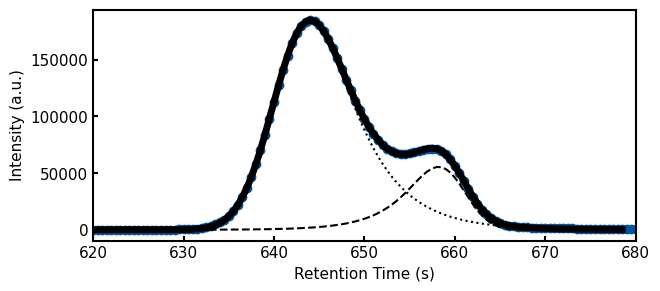

In [ ]:
#Unconstrained fit
print('Unconstrained fit')
print('-'*80)
print(sample_name)
print('-'*80)

initial_guess = [1e5, 644, 3.625, 0.33, 1e4, 660, 2.665, 0.1634]                        
lower_bounds = [0, 640, 0, 0, 0, 658, 0, 0]
upper_bounds = [np.inf, 645, 4, 0.7, np.inf, 666, 3, 0.3]
popt, _ = sc.optimize.curve_fit(EMGsTailFront, sample[index_1:index_2,0], sample[index_1:index_2,1],
                                p0 = initial_guess, bounds = [lower_bounds, upper_bounds])
h1, mu1, sigma1, tau1 = popt[:4]
h2, mu2, sigma2, tau2 = popt[4:]

#calculate fit functions
EMG_FAld = EMG(sample[index_1:index_2,0], h1, mu1, sigma1, tau1)
EMG_FA   = EMG_mirrored(sample[index_1:index_2,0], h2, mu2, sigma2, tau2)

#Methanol:
mask = (sample[:,0] > 850) & (sample[:,0] < 950)
index_3, index_4 = np.argmax(sample[:, 1][mask])-70, np.argmax(sample[:, 1][mask])+70
index_3_full, index_4_full = np.where(mask)[0][index_3], np.where(mask)[0][index_4]
integral_MeOH = trapezoid(sample[index_3_full:index_4_full,1], sample[index_3_full:index_4_full,0], axis=0)
concentration_MeOH = integral_MeOH/MeOH['slope']
peak_time = sample[mask][np.argmax(sample[mask][:,1]),0]

# Table for popt parameters, concentration and peak position
print(f"{'Peak':<10} {'h':<12} {'mu':<10} {'sigma':<10} {'tau':<10} {'[wt%]':<12} {'Peak pos.':<12}")
print("-" * 80)
print(f"{'FAld':<10} {h1:<12.2f} {mu1:<10.3f} {sigma1:<10.3f} {tau1:<10.3f} {h1/FAld['slope']:<12.2f} {sample[index_1:index_2,0][np.argmax(EMG_FAld)]:<12.2f}")
print(f"{'FA':<10} {h2:<12.2f} {mu2:<10.3f} {sigma2:<10.3f} {tau2:<10.3f} {h2/FA['slope']:<12.2f} {sample[index_1:index_2,0][np.argmax(EMG_FA)]:<12.2f}")
print(f"{'MeOH':<10} {'-'*40} {' '*4} {concentration_MeOH:<12.2f} {peak_time:<12.2f}")

#plot 
fig, ax = plt.subplots()
ax.plot(sample[:,0], sample[:,1], 'C0o')
ax.plot(sample[index_1:index_2,0], EMG_FAld, 'k:')
ax.plot(sample[index_1:index_2,0], EMG_FA, 'k--')
ax.plot(sample[index_1:index_2,0], EMG_FAld+EMG_FA, 'k-', lw = 5)

ax.set_xlim(620, 680)
#ax.set_ylim(0, 120000)
ax.set_xlabel('Retention Time (s)')
ax.set_ylabel('Intensity (a.u.)')
plt.show()

Constrained fit - only sigma
--------------------------------------------------------------------------------
FKE-EXP-022-HPLC-1
--------------------------------------------------------------------------------
Peak       h            mu         sigma      tau        [wt%]        Peak pos.   
--------------------------------------------------------------------------------
FAld       2110934.76   641.326    3.427      0.243      7.65         644.00      
FA         559168.54    660.478    2.306      0.227      4.16         658.00      
MeOH       ----------------------------------------      2.75         902.50      


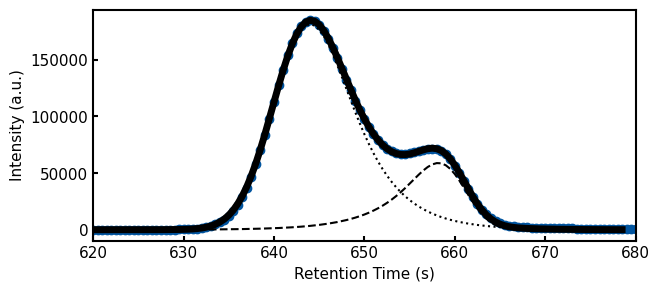

In [ ]:
# Constrained fit - only sigma
print('Constrained fit - only sigma')
print('-'*80)
print(sample_name)
print('-'*80)

# Use factory functions from fit_functions to avoid local duplicates
# Create sigma-constrained EMG functions using calibration coefficients
constrained_EMG = make_sigma_constrained_EMG(FAld_coeffs_wid)
constrained_EMG_mirrored = make_sigma_constrained_EMG_mirrored(FA_coeffs_wid)
constrained_EMGsTailFront = make_sigma_constrained_EMGsTailFront(FAld_coeffs_wid, FA_coeffs_wid)

# Fit values and print optimized parameters
initial_guess = [8e5, 644, 0.35, 1e4, 660, 0.13]
lower_bounds = [0, 640, 0, 0, 660, 0]
upper_bounds = [np.inf, 650, 0.5, np.inf, 666, 0.5]

popt, _ = sc.optimize.curve_fit(constrained_EMGsTailFront, sample[index_1:index_2,0], sample[index_1:index_2,1],
                                p0 = initial_guess, bounds = [lower_bounds, upper_bounds])
h1, mu1, tau1 = popt[:3]
sigma1 = FAld_coeffs_wid[1]+h1*FAld_coeffs_wid[0]
h2, mu2, tau2 = popt[3:]
sigma2 = FA_coeffs_wid[1]+h2*FA_coeffs_wid[0]

#calculate fit functions
EMG_FAld = constrained_EMG(sample[index_1:index_2,0], h1, mu1, tau1)
EMG_FA   = constrained_EMG_mirrored(sample[index_1:index_2,0], h2, mu2, tau2)

#Methanol:
mask = (sample[:,0] > 850) & (sample[:,0] < 950)
index_3, index_4 = np.argmax(sample[:, 1][mask])-70, np.argmax(sample[:, 1][mask])+70
index_3_full, index_4_full = np.where(mask)[0][index_3], np.where(mask)[0][index_4]
integral_MeOH = trapezoid(sample[index_3_full:index_4_full,1], sample[index_3_full:index_4_full,0], axis=0)
concentration_MeOH = integral_MeOH/MeOH['slope']
peak_time = sample[mask][np.argmax(sample[mask][:,1]),0]

# Table for popt parameters, concentration and peak position (alles linksbündig)
print(f"{'Peak':<10} {'h':<12} {'mu':<10} {'sigma':<10} {'tau':<10} {'[wt%]':<12} {'Peak pos.':<12}")
print("-" * 80)
print(f"{'FAld':<10} {h1:<12.2f} {mu1:<10.3f} {sigma1:<10.3f} {tau1:<10.3f} {h1/FAld['slope']:<12.2f} {sample[index_1:index_2,0][np.argmax(EMG_FAld)]:<12.2f}")
print(f"{'FA':<10} {h2:<12.2f} {mu2:<10.3f} {sigma2:<10.3f} {tau2:<10.3f} {h2/FA['slope']:<12.2f} {sample[index_1:index_2,0][np.argmax(EMG_FA)]:<12.2f}")
print(f"{'MeOH':<10} {'-'*40} {' '*4} {concentration_MeOH:<12.2f} {peak_time:<12.2f}")

#plot 
fig, ax = plt.subplots()
ax.plot(sample[:,0], sample[:,1], 'C0o', label='Data')
ax.plot(sample[index_1:index_2,0], EMG_FAld, 'k:', label='FAld fit')
ax.plot(sample[index_1:index_2,0], EMG_FA, 'k--', label='FA fit')
ax.plot(sample[index_1:index_2,0], EMG_FAld+EMG_FA, 'k-', lw = 5, label='Sum fit')

ax.set_xlim(620, 680)
#ax.set_ylim(0, 120000)
ax.set_xlabel('Retention Time (s)')
ax.set_ylabel('Intensity (a.u.)')
ax.legend()
plt.show()

In [ ]:
M_FAld = 30
M_CH4O2 = 48
M_FA = 46
M_MeOH = 32
f = M_CH4O2/M_FAld
V = 100

SOL_008_2 = {
    'c0_FAld':14.74,
    'c0_MeOH': 1.11,
    'c0_FA': 0}
SOL_008_3 = {
    'c0_FAld':14.09,
    'c0_MeOH': 0.8,
    'c0_FA': 0}
SOL_008_4 = {
    'c0_FAld':15.33,
    'c0_MeOH': 0.8,
    'c0_FA': 0}

w0_CH4O2, w0_MeOH, w0_FA = SOL_008_4['c0_FAld']*V/(V+10)*f, SOL_008_4['c0_MeOH']*V/(V+10), SOL_008_4['c0_FA']                  
w1_CH4O2, w1_MeOH, w1_FA = h1/FAld['slope']*f, concentration_MeOH, h2/FA['slope']         
print(w1_CH4O2, w1_MeOH, w1_FA)

c_CH4O2 = (w0_CH4O2 - w1_CH4O2)/M_CH4O2 #used
c_FA = (w1_FA - w0_FA)/M_FA #produced
c_MeOH = (w1_MeOH-w0_MeOH)/M_MeOH #produced

H2_gen = 2*(c_CH4O2-c_FA-c_MeOH) + c_FA - c_MeOH
CO2_gen = (c_CH4O2-c_FA-c_MeOH)
print(f'CH4O2 >> CO2 + 2*H2: {c_CH4O2-c_FA-c_MeOH}')
print(f'CH4O2 >> H2 + FA: {c_FA}')
print(f'CH4O2 + H2 >> H2O + CH3OH: {c_MeOH}')
print(f'H2-to-CO2: {H2_gen/CO2_gen}')



12.236826220611198 2.7494319051844185 4.1586802200260555
CH4O2 >> CO2 + 2*H2: 0.0560130088999507
CH4O2 >> H2 + FA: 0.09040609173969685
CH4O2 + H2 >> H2O + CH3OH: 0.06319247430974034
H2-to-CO2: 2.4858445915405993


Constrained fit
--------------------------------------------------------------------------------
Peak       h            mu         sigma      tau        [wt%]        Peak pos.   
--------------------------------------------------------------------------------
FAld       1856995.21   641.748    3.436      0.333      6.73         644.00      
FA         817147.36    660.704    2.375      0.143      6.08         658.00      
MeOH       ----------------------------------------      2.75         902.50      


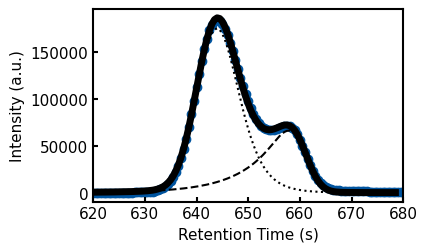

In [ ]:
#import chromatogram
print('Constrained fit')
print('-'*80)
path_35 = '../01_unprocessed_data/HPLC/Calibration/Calibration_35C/FA_FAld/'
files_35 = ['FKE-CAL-FALD-FA-HPLC-1.txt', 'FKE-CAL-FALD-FA-HPLC-2.txt', 'FKE-CAL-FALD-FA-HPLC-3.txt', 'FKE-CAL-FALD-FA-HPLC-4.txt']

path_35_2 = '../01_unprocessed_data/HPLC/Calibration/Calibration_35C/FA_FAld_2/'
files_35_2 = ['FKE-Test-FA-1.txt', 'FKE-Test-FA-2.txt', 'FKE-Test-FALD-1.txt', 'FKE-Test-FALD-2.txt', 'FKE-Test-FAFALD-1.txt', 'FKE-Test-FAFALD-2.txt']

# Use factory functions from fit_functions to build constrained models
constrained_EMG = make_constrained_EMG(FAld_coeffs_tau, FAld_coeffs_wid)
constrained_EMG_mirrored = make_constrained_EMG_mirrored(FA_coeffs_tau, FA_coeffs_wid)
constrained_EMGsTailFront = make_constrained_EMGsTailFront(
    FAld_coeffs_tau,
    FAld_coeffs_wid,
    FA_coeffs_tau,
    FA_coeffs_wid,
 )

initial_guess = [1e7, 644, 1e5, 658]                                                                                    # define initial guesses and bounds
lower_bounds = [1, 630, 1, 656]
upper_bounds = [np.inf, 645, np.inf, 665]

popt, _ = sc.optimize.curve_fit(constrained_EMGsTailFront, sample[index_1:index_2,0], sample[index_1:index_2,1],        # calculate popt
                                p0 = initial_guess, bounds = [lower_bounds, upper_bounds])

h1, mu1 = popt[:2]                                                                                                      # calculate sigma and tau
sigma1 = FAld_coeffs_wid[1]+h1*FAld_coeffs_wid[0]
tau1 = FAld_coeffs_tau[1]+h1*FAld_coeffs_tau[0]
h2, mu2 = popt[2:]
sigma2 = FA_coeffs_wid[1]+h2*FA_coeffs_wid[0]
tau2 = FA_coeffs_tau[1]+h2*FA_coeffs_tau[0]

EMG_FAld = constrained_EMG(sample[index_1:index_2,0], h1, mu1)                                                          # calculate fit functions
EMG_FA   = constrained_EMG_mirrored(sample[index_1:index_2,0], h2, mu2)

#Methanol:
mask = (sample[:,0] > 850) & (sample[:,0] < 950)
index_3, index_4 = np.argmax(sample[:, 1][mask])-70, np.argmax(sample[:, 1][mask])+70
index_3_full, index_4_full = np.where(mask)[0][index_3], np.where(mask)[0][index_4]
integral_MeOH = trapezoid(sample[index_3_full:index_4_full,1], sample[index_3_full:index_4_full,0], axis=0)
concentration_MeOH = integral_MeOH/MeOH['slope']
peak_time = sample[mask][np.argmax(sample[mask][:,1]),0]

print(f"{'Peak':<10} {'h':<12} {'mu':<10} {'sigma':<10} {'tau':<10} {'[wt%]':<12} {'Peak pos.':<12}")                   #print Peak pos and popt
print("-" * 80)
print(f"{'FAld':<10} {h1:<12.2f} {mu1:<10.3f} {sigma1:<10.3f} {tau1:<10.3f} {h1/FAld['slope']:<12.2f} {sample[index_1:index_2,0][np.argmax(EMG_FAld)]:<12.2f}")
print(f"{'FA':<10} {h2:<12.2f} {mu2:<10.3f} {sigma2:<10.3f} {tau2:<10.3f} {h2/FA['slope']:<12.2f} {sample[index_1:index_2,0][np.argmax(EMG_FA)]:<12.2f}")
print(f"{'MeOH':<10} {'-'*40} {' '*4} {concentration_MeOH:<12.2f} {peak_time:<12.2f}")

fig, ax = plt.subplots(figsize = (4,2.5))                                                                                #plot
ax.plot(sample[:,0], sample[:,1], 'C0o', label='Data')
ax.plot(sample[index_1:index_2,0], EMG_FAld, 'k:', label='FAld fit')
ax.plot(sample[index_1:index_2,0], EMG_FA, 'k--', label='FA fit')
ax.plot(sample[index_1:index_2,0], EMG_FAld+EMG_FA, 'k-', lw = 5, label='Sum fit')
ax.set_xlim(620, 680)
#ax.set_ylim(0, 120000)
ax.set_xlabel('Retention Time (s)')
ax.set_ylabel('Intensity (a.u.)')
ax.legend()
plt.show()